In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Task 1: Custom CNNs and Shortcut Learning

### Part A: Standard MNIST

In [2]:
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 32 * 3 * 3)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


In [3]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / len(loader), correct / total

In [6]:
model = CustomCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-"*30)

Epoch 1
Train Loss: 0.4034, Train Acc: 0.8722
Val Loss: 0.1312, Val Acc: 0.9576
------------------------------
Epoch 2
Train Loss: 0.1048, Train Acc: 0.9678
Val Loss: 0.0846, Val Acc: 0.9734
------------------------------
Epoch 3
Train Loss: 0.0757, Train Acc: 0.9770
Val Loss: 0.0748, Val Acc: 0.9762
------------------------------
Epoch 4
Train Loss: 0.0606, Train Acc: 0.9810
Val Loss: 0.0833, Val Acc: 0.9730
------------------------------
Epoch 5
Train Loss: 0.0527, Train Acc: 0.9832
Val Loss: 0.0594, Val Acc: 0.9818
------------------------------
Epoch 6
Train Loss: 0.0444, Train Acc: 0.9862
Val Loss: 0.0519, Val Acc: 0.9840
------------------------------
Epoch 7
Train Loss: 0.0372, Train Acc: 0.9880
Val Loss: 0.0520, Val Acc: 0.9849
------------------------------
Epoch 8
Train Loss: 0.0351, Train Acc: 0.9887
Val Loss: 0.0479, Val Acc: 0.9856
------------------------------
Epoch 9
Train Loss: 0.0301, Train Acc: 0.9905
Val Loss: 0.0488, Val Acc: 0.9848
------------------------------
E

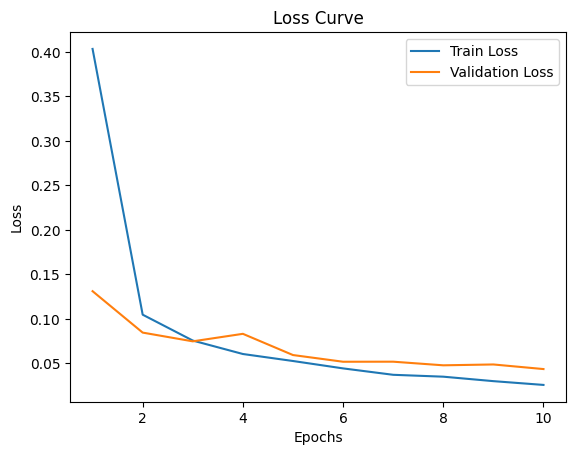

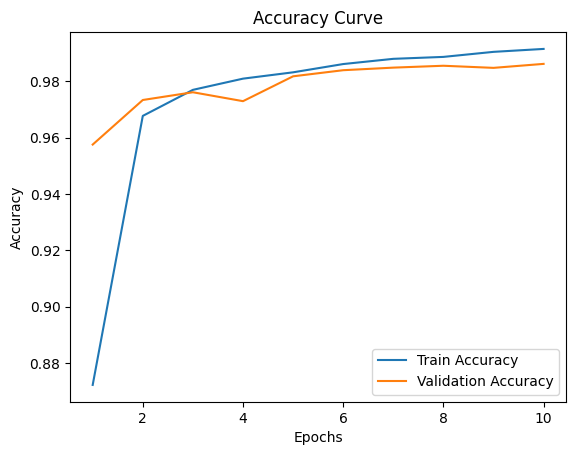

In [7]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [8]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9884


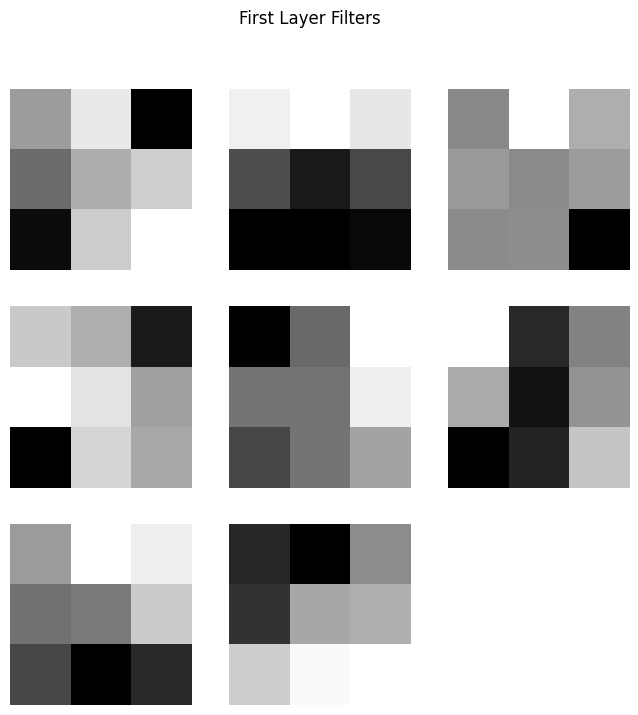

In [9]:
filters = model.conv1.weight.data.cpu()

plt.figure(figsize=(8,8))
for i in range(filters.shape[0]):
    plt.subplot(3,3,i+1)
    plt.imshow(filters[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle("First Layer Filters")
plt.show()

In [10]:
def count_parameters(model):
    total_params = 0
    for param in model.parameters():
        if param.requires_grad:
            total_params += param.numel()
    return total_params

total_params = count_parameters(model)
print(f"Total Trainable Parameters: {total_params}")

Total Trainable Parameters: 25034


#### Q 1.1

The model generalizes well with minimal overfitting.

Both training and validation loss decrease steadily, and the gap between them remains small throughout training. Validation accuracy closely follows training accuracy (~98–99%), indicating good generalization.

A slight gap appears in later epochs (train loss continues decreasing while validation stabilizes), suggesting minor overfitting, but it is not significant.

Q 1.2

The filters show basic edge and texture detection.

Several filters exhibit strong intensity transitions corresponding to horizontal and vertical edges with diagonal patterns and local contrast changes.

These filters capture low level spatial features such as edges and strokes, which are essential building blocks for recognizing digit shapes.

## Task 2: Transfer Learning and Interpretability

## Part B:  Colored-MNIST (C-MNIST)

In [11]:
import torch

train_data = torch.load('/content/drive/MyDrive/cmnist/train_biased.pt')
test_biased = torch.load('/content/drive/MyDrive/cmnist/test_biased.pt')
test_unbiased = torch.load('/content/drive/MyDrive/cmnist/test_unbiased.pt')

X_train, y_train = train_data
X_test_b, y_test_b = test_biased
X_test_u, y_test_u = test_unbiased

print(X_train.shape, y_train.shape)

torch.Size([60000, 3, 28, 28]) torch.Size([60000])


In [12]:
from torch.utils.data import Dataset

class CMNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.float()
        self.y = y.long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(CMNISTDataset(X_train, y_train), batch_size=64, shuffle=True)
test_b_loader = DataLoader(CMNISTDataset(X_test_b, y_test_b), batch_size=64, shuffle=False)
test_u_loader = DataLoader(CMNISTDataset(X_test_u, y_test_u), batch_size=64, shuffle=False)

In [14]:
class CustomCNN_RGB(nn.Module):
    def __init__(self):
        super(CustomCNN_RGB, self).__init__()

        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)  # FIXED
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 32 * 3 * 3)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [15]:
class CMNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.float() / 255.0   # 🔥 IMPORTANT FIX
        self.y = y.long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [16]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / len(loader), correct / total

In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / len(loader), correct / total

In [18]:
model = CustomCNN_RGB().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print("-"*30)

Epoch 1
Train Loss: 0.3349, Train Acc: 0.9220
------------------------------
Epoch 2
Train Loss: 0.0979, Train Acc: 0.9725
------------------------------
Epoch 3
Train Loss: 0.0611, Train Acc: 0.9823
------------------------------
Epoch 4
Train Loss: 0.0433, Train Acc: 0.9875
------------------------------
Epoch 5
Train Loss: 0.0336, Train Acc: 0.9896
------------------------------
Epoch 6
Train Loss: 0.0266, Train Acc: 0.9913
------------------------------
Epoch 7
Train Loss: 0.0233, Train Acc: 0.9929
------------------------------
Epoch 8
Train Loss: 0.0192, Train Acc: 0.9940
------------------------------
Epoch 9
Train Loss: 0.0172, Train Acc: 0.9948
------------------------------
Epoch 10
Train Loss: 0.0141, Train Acc: 0.9953
------------------------------


In [19]:
biased_loss, biased_acc = evaluate(model, test_b_loader, criterion)
unbiased_loss, unbiased_acc = evaluate(model, test_u_loader, criterion)

print(f"Biased Test Accuracy: {biased_acc:.4f}")
print(f"Unbiased Test Accuracy: {unbiased_acc:.4f}")

Biased Test Accuracy: 0.9939
Unbiased Test Accuracy: 0.9199


#### Q 1.3

The model achieves 99.39% accuracy on the biased test set and 91.99% on the unbiased test set, showing a clear performance drop.

This occurs because the model learns a function closer to:

Y ≈ f(color) instead of Y ≈ f(shape)

Mathematically, during training, the optimizer updates weights based on gradients:

Color is highly correlated with labels in the biased dataset which produces stronger, more consistent gradients and faster loss minimization.

As a result, the model prioritizes color (low-complexity feature) over shape (higher-complexity feature).

Conceptually, this is shortcut learning:

The model exploits an easy feature e.g is color here

#### Q 1.4

To force the model to focus on shape instead of color:

Data augmentation: Randomize or vary colors across samples

Remove correlation: Ensure color is not predictive of labels during training

Convert to grayscale: Eliminate color information entirely

Regularization: Penalize reliance on specific channels (e.g., dropout, weight decay)

Balanced dataset design: Each digit appears with multiple colors uniformly

Adversarial training: Encourage invariance to color perturbations

## Task 2: Transfer Learning and Interpretability

### Part A: Fine-tuning ResNet-18

In [4]:
import torchvision.models as models

model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
for param in model.parameters():
    param.requires_grad = False

In [6]:
model.fc = nn.Linear(model.fc.in_features, 10)

In [7]:
model = model.to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [9]:
from torchvision.datasets import STL10
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 🔥 IMPORTANT for ResNet
    transforms.ToTensor(),
])

train_dataset = STL10(root='./data', split='train', download=True, transform=transform)
test_dataset = STL10(root='./data', split='test', download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 2.64G/2.64G [07:11<00:00, 6.12MB/s]


In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 50 == 0:  # 🔥 ADD THIS
            print(f"Batch {i}/{len(loader)}")

    return total_loss / len(loader), correct / total

In [11]:
train_losses = []
train_accs = []

for epoch in range(5):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

Batch 0/79
Batch 50/79
Epoch 1
Train Loss: 0.9655, Train Acc: 0.7590
Batch 0/79
Batch 50/79
Epoch 2
Train Loss: 0.3336, Train Acc: 0.9270
Batch 0/79
Batch 50/79
Epoch 3
Train Loss: 0.2458, Train Acc: 0.9384
Batch 0/79
Batch 50/79
Epoch 4
Train Loss: 0.2102, Train Acc: 0.9456
Batch 0/79
Batch 50/79
Epoch 5
Train Loss: 0.1849, Train Acc: 0.9490


In [12]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"STL-10 Test Accuracy: {test_acc:.4f}")

STL-10 Test Accuracy: 0.9427


In [13]:
print(device)

cuda


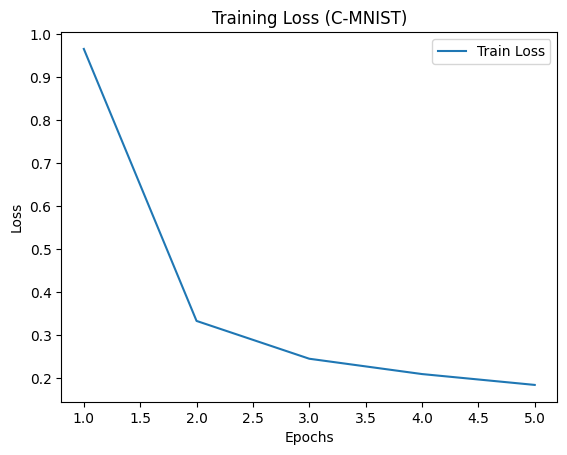

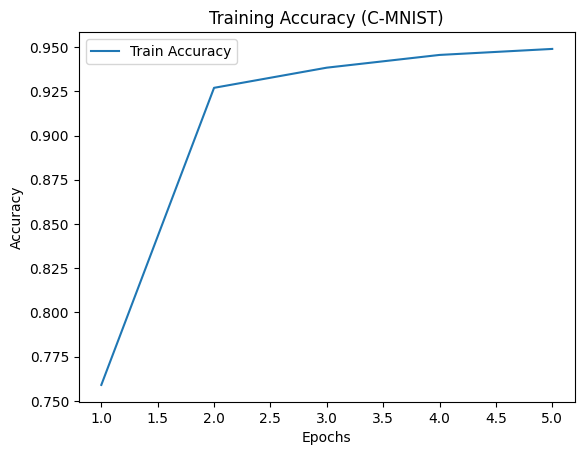

In [14]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss (C-MNIST)")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy (C-MNIST)")
plt.legend()
plt.show()

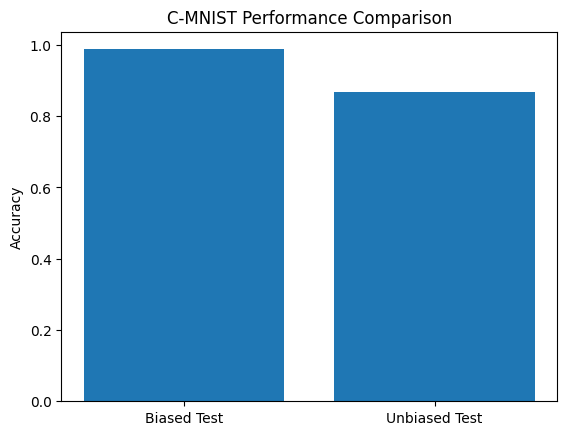

In [15]:
labels = ['Biased Test', 'Unbiased Test']
accuracies = [0.9878, 0.8671]

plt.figure()
plt.bar(labels, accuracies)
plt.ylabel("Accuracy")
plt.title("C-MNIST Performance Comparison")
plt.show()

#### Q 2.1

Freezing the early layers is both computationaly efficient and effective because as the trainable parameters are reduced. During training, gradients are computed only for the final classification layer rather than the entire network. This leads to faster training, lower memory consumption and a stable optimization.

This efficiency is evident in the training process, where the model quickly converges within a few epochs, achieving a training accuracy of ~94.9% and a test accuracy of 94.27%, despite only updating a small portion of the network.

Since STL-10 is relatively small, training a deep network from scratch would likely result in overfitting due to insufficient data. By freezing the early layers, the model leverages robust, pre-learned feature representations from large-scale datasets, while only adapting the final classification layer to the new task.

This approach allows the model to retain strong general visual features and avoid overfitting.


### Part B: Visualizing Decisions with GradCAM

In [16]:
!pip install grad-cam

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import numpy as np
import cv2

In [18]:
target_layer = model.layer4[-1]

In [19]:
def preprocess_image(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)  # C,H,W → H,W,C
    img = img.astype(np.float32)

    # Normalize between 0–1
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    return img

In [24]:
correct_samples = []
incorrect_samples = []

model.eval()

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(images)):
        if preds[i] == labels[i] and len(correct_samples) < 2:
            correct_samples.append((images[i], labels[i], preds[i]))
        elif preds[i] != labels[i] and len(incorrect_samples) < 2:
            incorrect_samples.append((images[i], labels[i], preds[i]))

    if len(correct_samples) >= 2 and len(incorrect_samples) >= 2:
        break

In [28]:
cam = GradCAM(model=model, target_layers=[target_layer])

In [29]:
def visualize_gradcam(sample, title):
    image_tensor, label, pred = sample

    input_tensor = image_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad = True   # 🔥 IMPORTANT

    targets = [ClassifierOutputTarget(pred.item())]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img = preprocess_image(image_tensor)

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    plt.figure()
    plt.imshow(visualization)
    plt.title(f"{title} | True: {label.item()} Pred: {pred.item()}")
    plt.axis('off')
    plt.show()

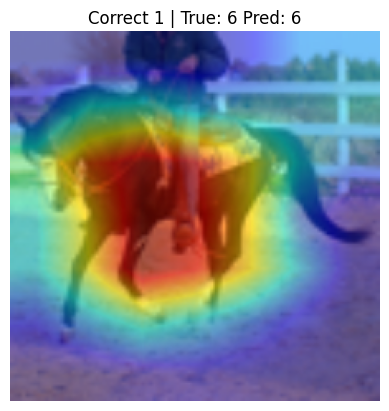

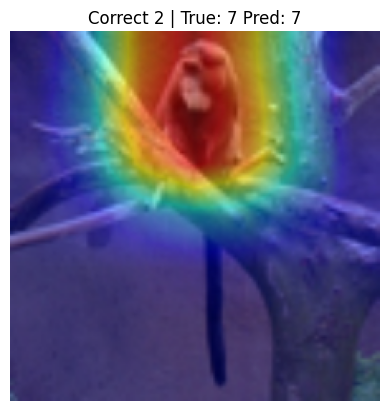

In [30]:
for i, sample in enumerate(correct_samples):
    visualize_gradcam(sample, f"Correct {i+1}")

#### Q 2.2

This visualization shows that for the correctly marked images, the model is focusing the main object of interest rather than the background, so it can check the main features.

In the first image, the heatmap focuses on the horse's body and torso, around the central mass and legs. This indicates that the model is attending to the structural features of the horse, such as shape and posture, which are essential for correct classification.

In the second image, the heatmap is focused on the bird itself while not. much focused on the surrondings. This suggests that the model is successfully isolating the object from its context and focusing on discriminative features such as shape and texture.

This shows model is focusing on good semantically meaningful regions and shows good model learning w.r.t to features

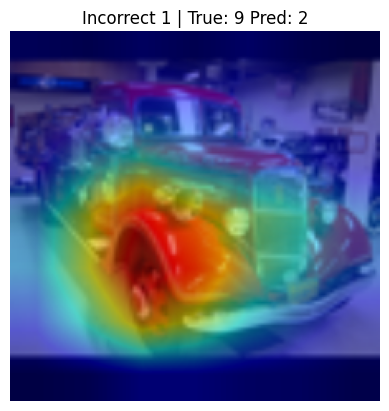

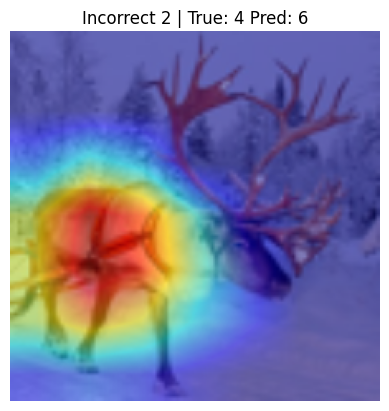

In [31]:
# Incorrect predictions
for i, sample in enumerate(incorrect_samples):
    visualize_gradcam(sample, f"Incorrect {i+1}")

#### Q 2.3

In this case, the model is focusing on misleading or incomplete regions.

The first image is of a truck but classifed as a bird because the heatmap is concentrated on the front wheel and lower portion of the vehicle, rather than the full structure of the truck. By focusing on a localized circular shape and metallic texture, the model fails to capture the global context of the object. Showing that model relied on partial features for this one.

In the second image, (true: deer, predicted: horse), the heatmap highlights primarily the body of the animal, but does not strongly emphasize distinguishing features such as the antlers. Since deer and horses share similar body structures, ignoring key discriminative features leads to confusion between the two classes.

So, in these cases the model attends to localized and partial features and ignored the class specific features like the antlers. Which resulted in incorrect interpretation of the scene.